# Twitter Hangulatelemzés - Megoldás

In [ ]:
# @title Függőségek Telepítése
!pip install pandas --quiet
!pip install torchtext --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 48.3 MB/s eta 0:00:00


In [ ]:
# @title Tweet Adathalmaz Letöltése (Sentiment140)
# Eredeti Google Drive link már nem elérhető.
# Alternatíva: tölts le a Kaggle-ről:
# https://www.kaggle.com/datasets/kazanova/sentiment140

# Kaggle CLI-vel:
# !pip install -q kaggle
# !kaggle datasets download -d kazanova/sentiment140
# !unzip -qq sentiment140.zip

# Eredeti (nem elérhető):
# !gdown -qq 1penca66caOrgagaQvrKCBDrCN_g1ZN35
# !unzip -qq twitter.zip -d .
# !rm -rf twitter.zip

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import torchtext
from torchtext.data import get_tokenizer

from sklearn.utils import shuffle
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

/usr/local/lib/python3.10/dist-packages/torchtext/data/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)


In [ ]:
header_list = ["target", "id", "date", "query", "user", "text"]
df = pd.read_csv('training.1600000.processed.noemoticon.csv',
                 encoding = "ISO-8859-1", names=header_list)
print("Tweet-ek száma:", len(df))
df.head()

Tweet-ek száma: 1600000


,target,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [ ]:
X = df.text.values

# Changes values from [0,4] to [0,1]
y = (df.target.values > 1).astype(int)

# Split the data into train and test
x_train_text, x_test_text, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [ ]:
for s, l in zip(x_train_text[:5], y_train[:5]):
  print('{}: {}'.format(l, s))

1: @paisleypaisley LOL why do i get ideas so far in advance? it's not even june yet! we need a third knitter to have our own summer group 
0: worst headache ever 
0: @ewaniesciuszko  i am so sad i wont see you! I miss you already. and yeah! that's perfect; i come back the 18th!
1: doesn't know how to spell conked 
0: &quot;So we stand here now and no one knows us at all I won't get used to this I won't get used to being gone&quot;...I miss home and everyone  -a


In [ ]:
tokenizer = get_tokenizer("basic_english")

print('Before Tokenize: ', x_train_text[1])
print('After Tokenize: ', tokenizer(x_train_text[1]))

Before Tokenize:  worst headache ever 
After Tokenize:  ['worst', 'headache', 'ever']


In [ ]:
x_train_token = [tokenizer(s) for s in tqdm(x_train_text)]
x_test_token = [tokenizer(s) for s in tqdm(x_test_text)]

  0%|          | 0/1280000 [00:00<?, ?it/s]

  0%|          | 0/320000 [00:00<?, ?it/s]

In [ ]:
words = Counter()
for s in x_train_token:
  for w in s:
    words[w] += 1

sorted_words = list(words.keys())
sorted_words.sort(key=lambda w: words[w], reverse=True)
print(f"Number of different Tokens in our Dataset: {len(sorted_words)}")
print(sorted_words[:100])

Number of different Tokens in our Dataset: 669284
['.', 'i', '!', "'", 'to', 'the', ',', 'a', 'my', 'it', 'and', 'you', '?', 'is', 'for', 'in', 's', 'of', 't', 'on', 'that', 'me', 'so', 'have', 'm', 'but', 'just', 'with', 'be', 'at', 'not', 'was', 'this', 'now', 'can', 'good', 'up', 'day', 'all', 'get', 'out', 'like', 'are', 'no', 'go', 'http', '-', 'today', 'do', 'too', 'your', 'work', 'going', 'love', 'we', 'got', 'what', 'lol', 'time', 'back', 'from', 'u', 'one', 'will', 'know', 'about', 'im', 'really', 'don', 'am', 'had', ')', 'see', 'some', 'there', 'its', '&amp', 'how', 'if', 'still', 'they', '&quot', 'night', '(', 'well', 'want', 'new', 'think', '2', 'home', 'thanks', 'll', 'oh', 'when', 'as', 'he', 'more', 'here', 'much', 'off']


In [ ]:
count_occurences = sum(words.values())

accumulated = 0
counter = 0

while accumulated < count_occurences * 0.8:
  accumulated += words[sorted_words[counter]]
  counter += 1

print(f"The {counter * 100 / len(words)}% most common words "
      f"account for the {accumulated * 100 / count_occurences}% of the occurrences")

The 0.13970153178620734% most common words account for the 80.00532743602652% of the occurrences


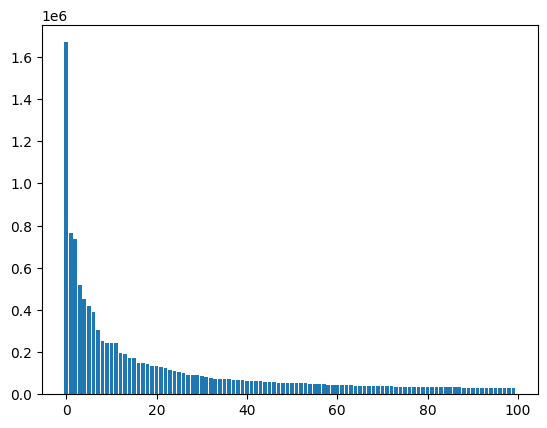

In [ ]:
plt.bar(range(100), [words[w] for w in sorted_words[:100]])
plt.show()

In [ ]:
vectorizer = CountVectorizer(binary=True)
x_train_cv = vectorizer.fit_transform(x_train_text)
x_test_cv = vectorizer.transform(x_test_text)

In [ ]:
print('Before Vectorize: ', x_train_text[3])

Before Vectorize:  doesn't know how to spell conked 


In [ ]:
print('After Vectorize: ')
print(x_train_cv[3])

After Vectorize: 
  (0, 528584)	1
  (0, 165468)	1
  (0, 300381)	1
  (0, 242211)	1
  (0, 489893)	1
  (0, 134160)	1


In [ ]:
model = LogisticRegression(solver='saga')
model.fit(x_train_cv, y_train)

LogisticRegression(solver='saga')

In [ ]:
y_pred = model.predict(x_test_cv)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.79      0.80    160000
           1       0.79      0.81      0.80    160000

    accuracy                           0.80    320000
   macro avg       0.80      0.80      0.80    320000
weighted avg       0.80      0.80      0.80    320000



In [ ]:
print(model.coef_.shape)
print(len(vectorizer.vocabulary_))

words_sk = list(vectorizer.vocabulary_.keys())
words_sk.sort(key=lambda w: model.coef_[0, vectorizer.vocabulary_[w]])

(1, 589260)
589260


In [ ]:
for w in words_sk[:20]:
  print('{}: {}'.format(w, model.coef_[0, vectorizer.vocabulary_[w]]))

roni: -3.862607287780589
inaperfectworld: -3.573436068795999
dontyouhate: -3.5002310097721265
xbllygbsn: -3.4126986845009077
anqju: -3.3364255487242684
sad: -3.200517581968939
pakcricket: -3.1948803846499167
condolences: -3.132530373655232
heartbreaking: -3.0665181030753077
saddest: -3.042029945913809
sadd: -3.0290744631086093
heartbroken: -3.028780171301457
boohoo: -3.0225949020493426
sadface: -2.99187316804072
rachelle_lefevr: -2.9250156782735752
disappointing: -2.9025347294449584
lvbu: -2.8947068588000477
saddens: -2.885517286490076
bummed: -2.836501901900933
neda: -2.7929532546813163


In [ ]:
for w in reversed(words_sk[-20:]):
  print('{}: {}'.format(w, model.coef_[0, vectorizer.vocabulary_[w]]))

iamsoannoyed: 2.849431277043979
myfax: 2.797464414911158
jennamadison: 2.5667241663551845
yeyy: 2.478022834595052
tryout: 2.4383359433438403
goldymom: 2.437399414512558
wooohooo: 2.402958553032287
thesupergirl: 2.356507245605582
iammaxathotspot: 2.3116541141201665
londicreations: 2.307422610780556
smilin: 2.299177746151629
worries: 2.289941777709275
sinfulsignorita: 2.279897817075883
finchensnail: 2.2642806492713117
smackthis: 2.2376611840271483
kv: 2.2158454017433997
tojosan: 2.2117893932426806
russmarshalek: 2.2094927173624628
traciknoppe: 2.1768568825937704
congratulations: 2.1715894292671734
